In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [60]:
###############
## FUNCTIONS ##
###############

class AttentionLastAggregator(nn.Module):
    def __init__(self, n_features, n_output=1, n_hidden=256):
        super(AttentionLastAggregator, self).__init__()

        self.al = nn.Sequential(nn.Linear(n_features, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_output), nn.Softmax(dim=1))
        self.pl = nn.Sequential(nn.Linear(n_features, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_output))
        self.link = nn.Sigmoid()
    
    def forward(self, x):
        a = self.al(x)
        p = self.pl(x)
        o = torch.sum(a*p, dim=1)
        return [a, p]

def generate_simulated_data(batch_size, n_features):
    # Generate simulated feature matrices with random or white noise data
    return torch.randn(batch_size, n_features)

def perform_sensitivity_analysis(model, simulated_data):
    # Pass simulated feature matrices through the model
    with torch.no_grad():
        predictions_a, predictions_p = model(simulated_data)
    return [predictions_a, predictions_p]

def visualize_correlations(predicted_labels):
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(predicted_labels.detach().numpy().T)
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
    plt.colorbar()
    plt.title('Correlation Matrix of Predicted Labels')
    plt.xlabel('Label Index')
    plt.ylabel('Label Index')
    plt.show()

def visualize_pairwise_outputs(predicted_labels):
    # Convert predicted_labels tensor to numpy array
    predicted_labels_np = predicted_labels.detach().cpu().numpy()    

    ## Figure
    n_labels = predicted_labels.shape[1]
    fig, axes = plt.subplots(n_labels, n_labels, figsize=(8,8))
    
    # Create scatter plot for pairwise outputs    
    pairs_x = []
    pairs_y = []
    for i in range(n_labels):
        for j in range(n_labels):            
            if i == j:                
                axes[i,j].scatter([-1, 1], [-1, 1], alpha=0.0) 
                axes[i,j].text(0, 0, f'V{i}', va='center', ha='center', fontsize=12)
            else:
                axes[i,j].scatter(predicted_labels_np[:,i], predicted_labels_np[:,j], alpha=0.5, s=0.1)
            # axes[i,j].set_xlabel(f'Predicted label {i}')
            # axes[i,j].set_ylabel(f'Predicted label {j}')
            axes[i,j].set_xticks([])
            axes[i,j].set_yticks([])

    ## End plot
    # plt.grid(True)
    # plt.tight_layout()    
    plt.show()

#
###

In [74]:
# Example usage:
n_features = 128
n_classes = 17
batch_size = 1000

# Initialize the model
pwd = '/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/PPCG_MQ_SmallMedium_Nozero_256_MultiTask/hypertrain_fold1/models/'
pt_aggregator = pwd + 'mod_agg_fold2_repeat0_bs16_ne32_lr0.001.pth'
model = AttentionLastAggregator(n_features, n_classes)
model.load_state_dict(torch.load(pt_aggregator))

# Generate simulated feature matrices
simulated_data = generate_simulated_data(batch_size, n_features)

# Perform sensitivity analysis
predictions_a, predictions_b = perform_sensitivity_analysis(model, simulated_data)
print(predictions_a.shape)
print(predictions_a.shape)

torch.Size([1000, 17])
torch.Size([1000, 17])


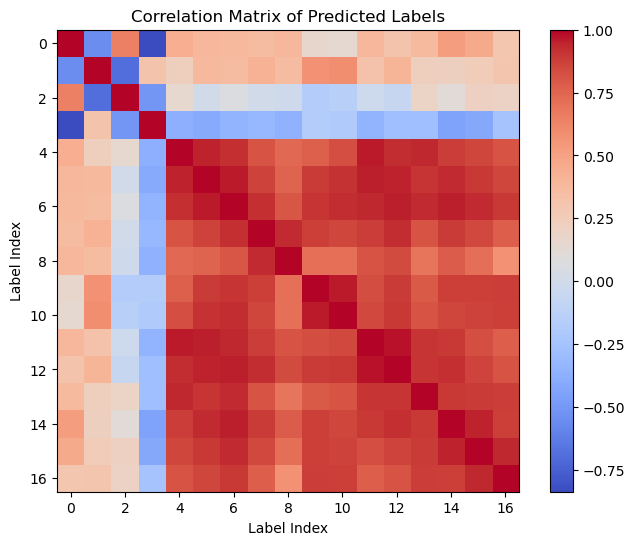

In [75]:
# Visualize correlations between predicted labels
# visualize_correlations(predictions_a)
visualize_correlations(predictions_b)

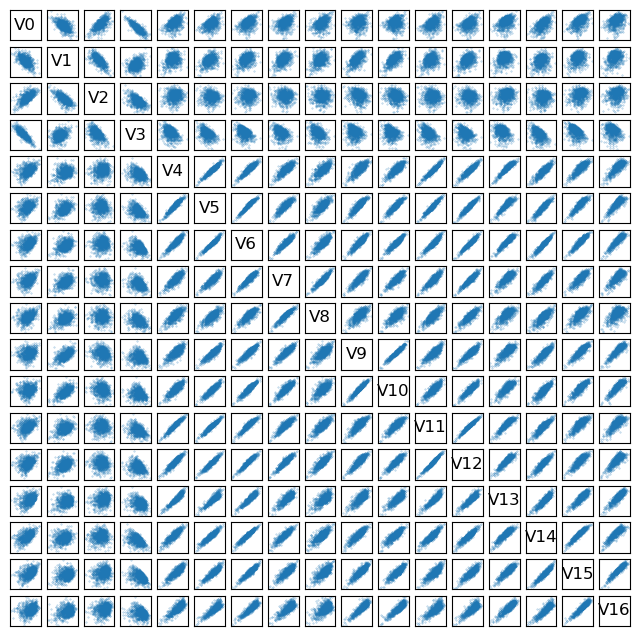

In [76]:
## Visualise correlations between predicted labels as scatter plots
# visualize_pairwise_outputs(predictions_a)
visualize_pairwise_outputs(predictions_b)